# Cognifyz Data Science Internship — Level 1

**Name:** Swapneel Popatarao Gayakawad
**Program:** Data Science Internship, Cognifyz IT Solutions Pvt. Ltd.
**Duration:** 24/08/2026 – 24/09/2026

This notebook covers all three Level 1 tasks on the Zomato restaurants dataset:

1. Data Exploration and Preprocessing
2. Descriptive Analysis
3. Geospatial Analysis

I've kept the code split into small steps so it's easy to follow what each part is doing, along with my observations after each output.


## Task 1: Data Exploration and Preprocessing

First I load the raw dataset and get a feel for its size and structure before doing any cleaning.

creating an separate folder for tasks regarding datascinece internship 

In [3]:
import pandas as pd

df = pd.read_csv("../Dataset.csv", encoding="utf-8-sig")  # utf-8-sig removes a hidden BOM character in the first column name
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


### 1.1 Checking the shape of the dataset
How many rows and columns am I working with?

In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 9551
Columns: 21


after running it checks the total rows and columns.

### 1.2 Checking for missing values
Before doing anything else I want to know which columns have gaps.

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

Cuisines    9
dtype: int64

Only `Cuisines` has missing values, and it's a tiny amount (9 out of 9551 rows, less than 0.1%).
Since it's a text/categorical column, I decided to fill the blanks with `"Unknown"` instead of dropping those rows — dropping felt wasteful for such a small gap, and `"Unknown"` keeps the row usable for the rest of the analysis.

In [6]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")
print(df.isnull().sum().sum(), "missing values remain")

0 missing values remain


### 1.3 Data type conversion
A few columns were stored as plain text even though they're really booleans or numbers, so I fixed those up.

In [7]:
df.dtypes

Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object

In [8]:
# Yes/No columns -> proper booleans
yes_no_cols = ["Has Table booking", "Has Online delivery", "Is delivering now", "Switch to order menu"]
for col in yes_no_cols:
    df[col] = df[col].map({"Yes": True, "No": False})

# Force the numeric columns to be numeric (in case of stray text/whitespace)
numeric_cols = ["Longitude", "Latitude", "Average Cost for two", "Price range", "Aggregate rating", "Votes"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Country Code is really a label, not a quantity, so I made it a category
df["Country Code"] = df["Country Code"].astype("category")

df.dtypes

Restaurant ID              int64
Restaurant Name              str
Country Code            category
City                         str
Address                      str
Locality                     str
Locality Verbose             str
Longitude                float64
Latitude                 float64
Cuisines                     str
Average Cost for two       int64
Currency                     str
Has Table booking           bool
Has Online delivery         bool
Is delivering now           bool
Switch to order menu        bool
Price range                int64
Aggregate rating         float64
Rating color                 str
Rating text                  str
Votes                      int64
dtype: object

### 1.4 Distribution of the target variable — `Aggregate rating`
This is the column most later analysis will care about, so I wanted to understand its spread and check for class imbalance.

In [9]:
df["Aggregate rating"].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

In [10]:
bins = [-0.1, 0, 1, 2, 3, 3.5, 4, 4.5, 5]
labels = ["0 (Not rated)", "0-1", "1-2", "2-3", "3-3.5", "3.5-4", "4-4.5", "4.5-5"]
df["rating_band"] = pd.cut(df["Aggregate rating"], bins=bins, labels=labels)

band_counts = df["rating_band"].value_counts().sort_index()
band_pct = (band_counts / len(df) * 100).round(2)

for band in labels:
    print(f"{band:15s}: {band_counts.get(band, 0):5d} rows  ({band_pct.get(band, 0):5.2f}%)")

0 (Not rated)  :  2148 rows  (22.49%)
0-1            :     0 rows  ( 0.00%)
1-2            :    10 rows  ( 0.10%)
2-3            :  1891 rows  (19.80%)
3-3.5          :  2502 rows  (26.20%)
3.5-4          :  1886 rows  (19.75%)
4-4.5          :   908 rows  ( 9.51%)
4.5-5          :   206 rows  ( 2.16%)


**My takeaway:** the mean (2.67) is a bit misleading on its own — about **22.5% of restaurants have a rating of exactly 0**, meaning they simply haven't been rated yet rather than being genuinely bad. If I set those aside, the actually-rated restaurants cluster heavily between **3.0 and 4.0** (roughly two-thirds of the dataset). Very few restaurants fall below 2 or above 4.5, so extreme ratings are rare — most places land somewhere in the "decent to good" range.

In [11]:
# Save the cleaned version so I can reuse it in Task 2 and Task 3 without redoing this cleanup
df.to_csv("cleaned_dataset.csv", index=False)
print("Saved cleaned_dataset.csv")

Saved cleaned_dataset.csv


## Task 2: Descriptive Analysis

Now that the data is cleaned, I moved on to summarizing it — basic stats for the numeric columns, and looking at how the categorical columns are distributed.

In [12]:
df = pd.read_csv("cleaned_dataset.csv")

numerical_cols = ["Average Cost for two", "Price range", "Aggregate rating", "Votes"]
df[numerical_cols].agg(["mean", "median", "std", "min", "max"]).round(2)

,Average Cost for two,Price range,Aggregate rating,Votes
mean,1199.21,1.80,2.67,156.91
median,400.00,2.00,3.20,31.00
std,16121.18,0.91,1.52,430.17
min,0.00,1.00,0.00,0.00
max,800000.00,4.00,4.90,10934.00


**Observation:** the mean and median for `Average Cost for two` are wildly different (₹1,199 vs ₹400) — a handful of very expensive outliers (max is ₹800,000!) are dragging the average up. Same pattern with `Votes` — a few extremely popular restaurants skew the mean well above the median. This tells me the median is a more honest "typical restaurant" summary than the mean for this dataset.

### Distribution of categorical columns

In [13]:
print(f"{df['Country Code'].nunique()} unique country codes")
df["Country Code"].value_counts().head(10)

15 unique country codes


Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64

In [14]:
print(f"{df['City'].nunique()} unique cities")
df["City"].value_counts().head(10)

141 unique cities


City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

### Top cuisines
The `Cuisines` column lists multiple cuisines per restaurant (e.g. "French, Japanese, Desserts"), so counting the raw column just counts *combinations*. I split them apart to find the most common individual cuisine types.

In [15]:
all_cuisines = df["Cuisines"].str.split(",").explode().str.strip()
all_cuisines.value_counts().head(10)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

**Observation:** `North Indian`, `Chinese`, and `Fast Food` are by far the most common cuisine types, and the top cities by restaurant count are all in the Delhi-NCR region (New Delhi, Gurgaon, Noida, Faridabad). This makes sense — Zomato's original dataset collection was heavily India-centric, so the descriptive stats naturally reflect Indian dining patterns rather than a globally balanced sample.

## Task 3: Geospatial Analysis

Finally, I looked at *where* these restaurants are located, and whether location has any relationship with rating.

In [16]:
import matplotlib.pyplot as plt

# 0,0 coordinates aren't real restaurant locations, so I filtered those out
geo_df = df[(df["Latitude"] != 0) & (df["Longitude"] != 0)].copy()
print(f"Using {len(geo_df)} of {len(df)} rows with valid coordinates.")

Using 9052 of 9551 rows with valid coordinates.


### Plotting restaurant locations
A world view first, then a zoomed-in view of India since that's where most of the data sits.

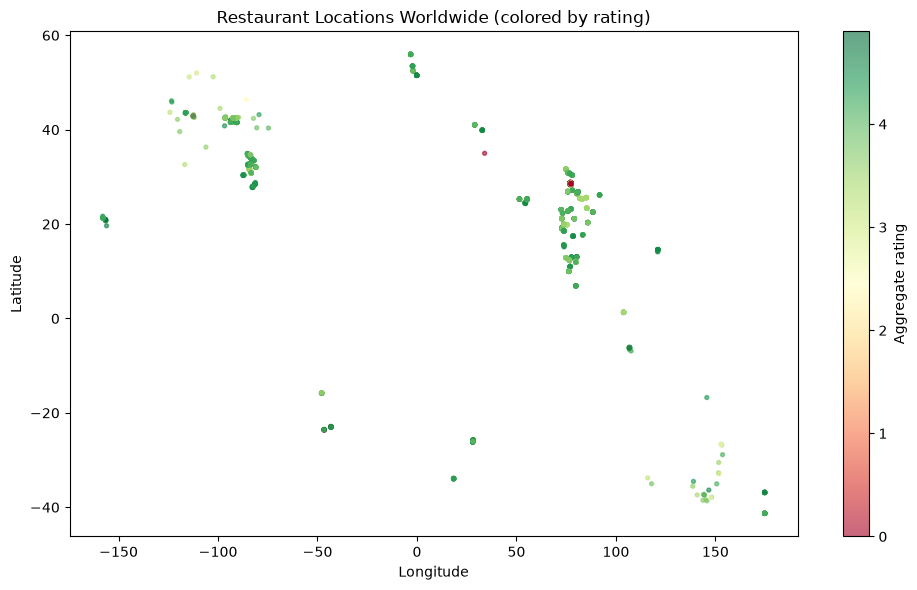

In [17]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(geo_df["Longitude"], geo_df["Latitude"],
                       c=geo_df["Aggregate rating"], cmap="RdYlGn", s=8, alpha=0.6)
plt.colorbar(scatter, label="Aggregate rating")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Restaurant Locations Worldwide (colored by rating)")
plt.tight_layout()
plt.show()

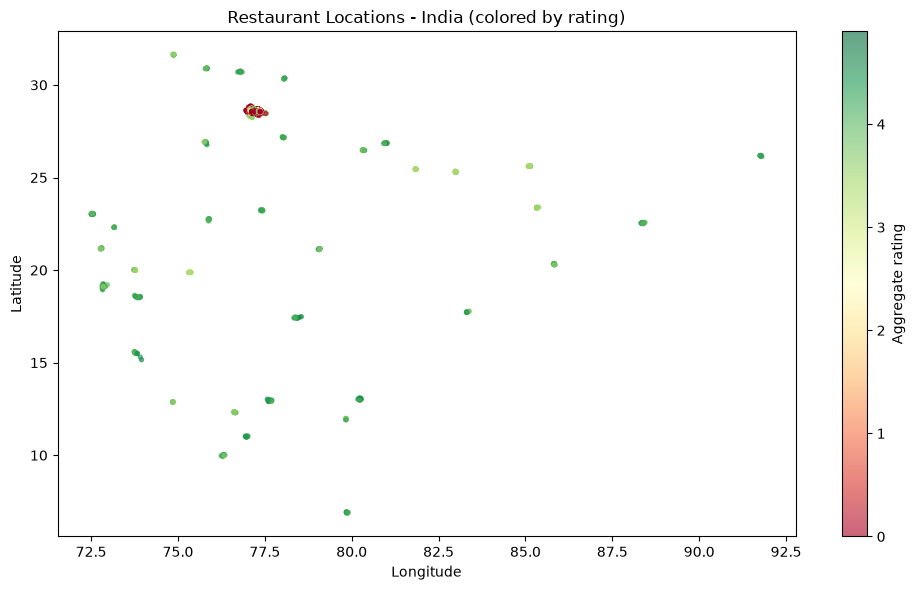

In [18]:
india_df = geo_df[(geo_df["Longitude"].between(68, 98)) & (geo_df["Latitude"].between(6, 38))]
plt.figure(figsize=(10, 6))
scatter = plt.scatter(india_df["Longitude"], india_df["Latitude"],
                       c=india_df["Aggregate rating"], cmap="RdYlGn", s=8, alpha=0.6)
plt.colorbar(scatter, label="Aggregate rating")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Restaurant Locations - India (colored by rating)")
plt.tight_layout()
plt.show()

### Distribution across cities and countries

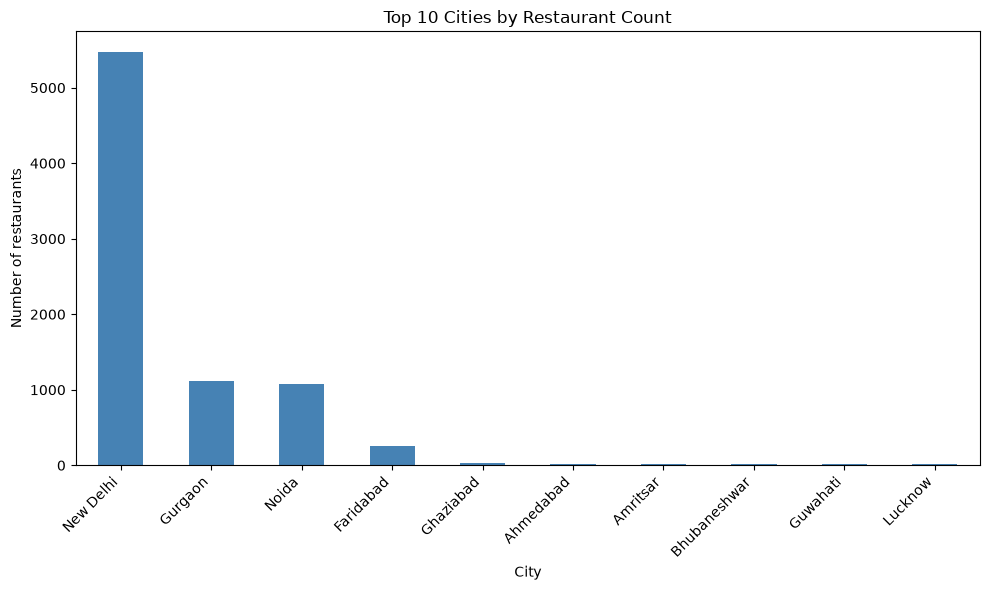

In [19]:
top_cities = df["City"].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_cities.plot(kind="bar", color="steelblue")
plt.ylabel("Number of restaurants")
plt.title("Top 10 Cities by Restaurant Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
country_counts = df["Country Code"].value_counts()
print(f"Restaurants span {df['Country Code'].nunique()} countries, but country code 1 (India)")
print(f"alone makes up {country_counts.iloc[0]} of {len(df)} rows ({country_counts.iloc[0] / len(df) * 100:.1f}%).")

Restaurants span 15 countries, but country code 1 (India)
alone makes up 8652 of 9551 rows (90.6%).


### Does location correlate with rating?

In [21]:
corr_lat = geo_df["Latitude"].corr(geo_df["Aggregate rating"])
corr_lon = geo_df["Longitude"].corr(geo_df["Aggregate rating"])
print(f"Correlation (Latitude  vs Aggregate rating): {corr_lat:.4f}")
print(f"Correlation (Longitude vs Aggregate rating): {corr_lon:.4f}")

Correlation (Latitude  vs Aggregate rating): -0.1244
Correlation (Longitude vs Aggregate rating): -0.2065


Both correlations are close to zero, which tells me there's no meaningful *linear* relationship between a restaurant's raw coordinates and its rating — which makes sense, since latitude/longitude are just position labels, not quantities that should scale with quality. A more meaningful comparison is looking at **average rating per city** instead:

In [22]:
city_avg_rating = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)
city_counts = df["City"].value_counts()
valid_cities = city_counts[city_counts >= 5].index  # ignore cities with too few restaurants to be meaningful
city_avg_rating[city_avg_rating.index.isin(valid_cities)].head(10).round(2)

City
London            4.54
Orlando           4.47
Tampa Bay         4.41
Rest of Hawaii    4.41
Bangalore         4.38
Dubai             4.37
Jakarta           4.36
Hyderabad         4.34
Chennai           4.31
Ankara            4.30
Name: Aggregate rating, dtype: float64

**My takeaway:** cities like London, Orlando, and Bangalore have the highest *average* ratings (restricted to cities with at least 5 restaurants, so a single 5-star outlier doesn't dominate). Interestingly, despite New Delhi having by far the most restaurants, it doesn't appear in the top-rated cities list — quantity of restaurants and average quality aren't the same thing.

## Summary

Across all three Level 1 tasks:
- The dataset is clean after handling a small number of missing `Cuisines` values and fixing data types.
- Ratings are skewed by a large chunk of unrated (0) restaurants; among rated ones, most cluster in the 3.0–4.0 range.
- The dataset is heavily India/Delhi-NCR-centric, with North Indian and Chinese being the dominant cuisines.
- Raw geographic coordinates don't correlate meaningfully with rating, but rating *does* vary noticeably by city when aggregated.

*(Author: Swapneel Popatarao Gayakawad — Cognifyz Data Science Internship, Level 1)*